In [1]:
import numpy as np
import pandas as pd
import os, os.path,sys
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import scipy
import plotly.express as px
import plotly.graph_objects as go


In [2]:
ROOT_DIR = ''
# ROOT_DIR = ''
ROOT_DIR ='/home/sergi_alcala/sergi_data/AZTEC_extension/'
print(f'Root dir: {ROOT_DIR}')

Root dir: /home/sergi_alcala/sergi_data/AZTEC_extension/


In [3]:
def load_real_data(city):
    ''' Load the real data for the city.'''

    bordeaux = pd.read_csv(os.path.join(ROOT_DIR,f'./citys/{city}.csv'))
    #bordeaux = pd.read_csv(f'/home/sergi_alcala/AZTEC_extension/citys/{city}.csv')

    bordeaux.drop('date_time', axis=1, inplace=True)
    bordeaux = bordeaux.reindex(sorted(bordeaux.columns), axis=1)
    bordeaux = bordeaux.to_numpy()
    return bordeaux

In [4]:
def fun_test_index_start(city,delay):
    bordeaux= load_real_data(city)
    test_index_start = round(len(bordeaux)*0.8) + delay
    return test_index_start


In [5]:
## Normalize df , each column is normalized independently by its max value
def normalize_df(df):
    max_values = df.max(axis=0)
    df = df / max_values
    return df

## Return Max values of each column
def max_values_df(df):
    max_values = df.max(axis=0)
    return max_values

In [6]:
# Load Deepcog's forecast

def load_deepcog_forecast(city,alpha,delay,run):
    ''' Load the Deepcog's forecast for the city.'''
    np_load_len=np.load(f'/home/sergi_alcala/sergi_data/AZTEC_extension/{results_fpath}/{city}/Alpha_{alpha}/Deepcog_benchmark_delay_{delay}__gamma_2_deltax_005_simu{run-1}.npy')
    infocom_19 = np.zeros((np_load_len.shape[0], np_load_len.shape[1],  run))
    #infocom_19 = np.zeros((3577, len(services),  run))
   

    for seed in range(run):
        
            for ser in range(np_load_len.shape[1]):
            
                np_load=np.load(f'/home/sergi_alcala/sergi_data/AZTEC_extension/{results_fpath}/{city}/Alpha_{alpha}/Deepcog_benchmark_delay_{delay}__gamma_2_deltax_005_simu{seed}.npy')
                infocom_19[:, ser, seed] = np_load[:, ser]
    return infocom_19
                
             

In [7]:
def load_scalers(city,delay):
    bench_scaler = pickle.load(open(f'/home/sergi_alcala/sergi_data/AZTEC_extension/{results_fpath}/{city}/Deepcog_benchmark_delay_{delay}_block_1_minmaxscaler.pkl', 'rb'))
    return bench_scaler

In [8]:
def denormalize_normalize(infocom_19,bench_scaler,Output_df,run):
    normalizer_value= 10e9
    infocom_19_denorm = np.zeros(infocom_19.shape)
    for i in range(run):
        infocom_19_denorm[:,:,i] = bench_scaler.inverse_transform(infocom_19[:,:,i])

    infocom_19_norm=infocom_19_denorm/normalizer_value
    Output_df_norm = Output_df/normalizer_value
    return infocom_19_norm,Output_df_norm
    

In [9]:
def fun_total_cost(Output_df_norm,infocom_19_norm,alpha,max_concatenated,phi,services,run,eta):
# def fun_total_cost(Output_df_norm,infocom_19_norm,city_df,alpha,num_services,phi,delta_demand):
    gamma = 2
    Output_df_denorm= Output_df_norm*10e9
    infocom_19_denorm= infocom_19_norm*10e9
   
    ### OVERPROVISIONING ###
    cost_overprovisioning_infocom = np.zeros(run)

    test_length=min(len(Output_df_norm),len(infocom_19_norm))

    cost_normalization_factor = (Output_df_denorm[:test_length].max(axis=0)
                                - Output_df_denorm[:test_length]).sum() * gamma

    for seed in range(run):
        cost_overprovisioning_infocom[seed] = (infocom_19_denorm[:test_length, :, seed] 
                                                - Output_df_denorm[:test_length]).clip(min=0).sum(axis=0).sum()
                                                
    cost_overprovisioning_infocom = cost_overprovisioning_infocom.mean(axis=-1) * gamma / cost_normalization_factor

    ### SLA ###
    slas_infocom_19 = np.zeros((len(services), run))


    for app in range(len(services)):
        for seed in range(run):
            slas_infocom_19[ app, seed] = np.where((infocom_19_denorm[:test_length, app, seed] 
                                                    - Output_df_denorm[:test_length, app]) < 0)[0].shape[0]
            
    cost_slas_infocom_19 = (slas_infocom_19.mean(axis=-1)*max_concatenated).sum()*alpha*gamma/cost_normalization_factor

    ### INSTANTIATION ###

    delta_demand_infocom_19 = np.zeros((infocom_19_denorm.shape[0], len(services), run))

    # for seed in range(run):
    #     for app in range(len(services)):
    #         delta_demand_infocom_19[:, app, seed] = (infocom_19_denorm[:, app,  seed] 
    #                                         - np.roll(infocom_19_denorm[:, app,  seed], 1))
    #         delta_demand_infocom_19[0, app,seed] = infocom_19_denorm[0, app, seed]

    
    for seed in range(run):
        for app in range(len(services)):
            delta_demand_infocom_19[:, app, seed] = (infocom_19_denorm[:, app,  seed] 
                                            - np.roll(infocom_19_denorm[:, app,  seed], 1,axis=0))
            delta_demand_infocom_19[0, app,seed] = infocom_19_denorm[0, app, seed]

    

    
    
    

    cost_instantiation_infocom19_prel = np.zeros((len(services), run))


    for app in range(len(services)):
        for seed in range(run):
            for time in range(test_length):
                if  delta_demand_infocom_19[time, app, seed] > 0:
                    cost_instantiation_infocom19_prel[app, seed] += np.min((Output_df_denorm[:test_length][time, app],
                                                                            infocom_19_denorm[time, app, seed]))

    #for i, element in enumerate(eta):
    
    cost_instantiation_infocom19= (cost_instantiation_infocom19_prel.mean(axis=-1)*
                                            eta).sum()/ cost_normalization_factor
        
    # for i in range(len(phi)):
    #     cost_instantiation_infocom19[i] = (cost_instantiation_infocom19_prel.mean(axis=-1)*
    #                                         max_concatenated*eta).sum()/ cost_normalization_factor
    
    ### RECONFIGURATION ###
    
    cost_reconfiguration_infocom_19_prel = np.zeros((len(services), run))
    
    for app in range(len(services)):
        for seed in range(run):
            index = np.where(delta_demand_infocom_19[:, app,  seed] != 0)[0]
            cost_reconfiguration_infocom_19_prel[ app, seed] = (np.min((Output_df_denorm[:test_length][index, app], 
                                                                infocom_19_denorm[index, app,  seed]),
                                                                    axis=0).sum(axis=0))
            
    cost_reconfiguration= cost_reconfiguration_infocom_19_prel.mean(axis=-1).sum()*phi/cost_normalization_factor
    
    total_cost = cost_overprovisioning_infocom + cost_slas_infocom_19 + cost_instantiation_infocom19 + cost_reconfiguration

    return total_cost,cost_overprovisioning_infocom,cost_slas_infocom_19,cost_instantiation_infocom19,cost_reconfiguration,delta_demand_infocom_19 ,index,cost_reconfiguration_infocom_19_prel


In [11]:
def cost_deepcog_analysis(city,alpha,delay,run,phi,services,eta,save_raw_data=False):

    city_df = pd.DataFrame(load_real_data(city))
    test_index_start = fun_test_index_start(city,delay)
    Output_df = city_df[test_index_start:]
    infocom_19 = load_deepcog_forecast(city,alpha,delay,run)
    bench_scaler=load_scalers(city,delay)
    infocom_19_norm,Output_df_norm=denormalize_normalize(infocom_19,bench_scaler,Output_df,run)

    Output_df_norm.reset_index(drop=True, inplace=True)
    Output_df_norm=Output_df_norm.to_numpy()
    max_concatenated = city_df.max(axis=0)
  
    


    total_cost,cost_overprovisioning_infocom,cost_slas_infocom_19,cost_instantiation_infocom19,cost_reconfiguration,delta_demand_infocom_19,index,cost_reconfiguration_infocom_19_prel= fun_total_cost(Output_df_norm,infocom_19_norm,alpha,max_concatenated,phi,services,run,eta)
    if save_raw_data:
        if not os.path.exists(f'/home/sergi_alcala/sergi_data/AZTEC_extension/{results_fpath}/{city}/Alpha_{alpha}/raw_data_{results_fpath}'):
            os.makedirs(f'/home/sergi_alcala/sergi_data/AZTEC_extension/{results_fpath}/{city}/Alpha_{alpha}/raw_data_{results_fpath}')

        np.save(f'/home/sergi_alcala/sergi_data/AZTEC_extension/{results_fpath}/{city}/Alpha_{alpha}/raw_data_{results_fpath}/Output_df_norm.npy', Output_df_norm)
        np.save(f'/home/sergi_alcala/sergi_data/AZTEC_extension/{results_fpath}/{city}/Alpha_{alpha}/raw_data_{results_fpath}/infocom_19_norm.npy', infocom_19_norm)
        np.save(f'/home/sergi_alcala/sergi_data/AZTEC_extension/{results_fpath}/{city}/Alpha_{alpha}/raw_data_{results_fpath}/cost_overprovisioning_infocom.npy', cost_overprovisioning_infocom)
        np.save(f'/home/sergi_alcala/sergi_data/AZTEC_extension/{results_fpath}/{city}/Alpha_{alpha}/raw_data_{results_fpath}/cost_slas_infocom_19.npy', cost_slas_infocom_19)
        np.save(f'/home/sergi_alcala/sergi_data/AZTEC_extension/{results_fpath}/{city}/Alpha_{alpha}/raw_data_{results_fpath}/cost_instantiation_infocom19.npy', cost_instantiation_infocom19)
        np.save(f'/home/sergi_alcala/sergi_data/AZTEC_extension/{results_fpath}/{city}/Alpha_{alpha}/raw_data_{results_fpath}/cost_reconfiguration.npy', cost_reconfiguration)
        

    
    return total_cost,cost_overprovisioning_infocom,cost_slas_infocom_19,cost_instantiation_infocom19,cost_reconfiguration,delta_demand_infocom_19,index,cost_reconfiguration_infocom_19_prel


In [12]:
city='Paris'
delay=1
alphas=[2,3,5]
alpha=0.7
phis=[0.1,0.5,1,10]
phi=0.1

run=10
gamma=2
services = ['youtube', 'snapchat', 'facebook', 'itunes', 'instagram']

In [10]:
cities=['Paris']
ALPHAS=[2]
PHIS=[0.1]
eta=2
delay=1
run=1
services = ['youtube', 'snapchat', 'facebook', 'itunes', 'instagram']
gamma=2

total_cost_list=[]
cost_overprovisioning_infocom_list=[]
cost_slas_infocom_19_list=[]
cost_instantiation_infocom19_list=[]
cost_reconfiguration_list=[]
sla_perc_list_index_list=[]

results_fpath = 'Deepcog_Results'
save_raw_data =False
for city in cities:
    for phi in PHIS:
        for alpha in ALPHAS:
            city_df = pd.DataFrame(load_real_data(city))
            test_index_start = fun_test_index_start(city,delay)
            Output_df = city_df[test_index_start:]
            infocom_19 = load_deepcog_forecast(city,alpha,delay,run)
            bench_scaler=load_scalers(city,delay)
            infocom_19_norm,Output_df_norm=denormalize_normalize(infocom_19,bench_scaler,Output_df,run)

            Output_df_norm.reset_index(drop=True, inplace=True)
            Output_df_norm=Output_df_norm.to_numpy()
            max_concatenated = city_df.max(axis=0)
        
            # total_cost,cost_overprovisioning_infocom,cost_slas_infocom_19,cost_instantiation_infocom19,cost_reconfiguration,delta_demand_infocom_19,index,cost_reconfiguration_infocom_19_prel=cost_deepcog_analysis(city,alpha,delay,run,phi,services,eta)
            # sla_perc_list_index=f'{city}_phi_{phi}_alpha_{alpha}_delay_{delay}'
            # sla_perc_list_index_list.append(sla_perc_list_index)
            # total_cost_list.append(total_cost)
            # cost_overprovisioning_infocom_list.append(cost_overprovisioning_infocom)
            # cost_slas_infocom_19_list.append(cost_slas_infocom_19)
            # cost_instantiation_infocom19_list.append(cost_instantiation_infocom19)
            # cost_reconfiguration_list.append(cost_reconfiguration)
            
            

/home/sergi_alcala/.local/lib/python3.10/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.1.1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [11]:
infocom_19_norm = infocom_19_norm[:,:,0]

In [12]:
Output_df_norm.shape

(3581, 5)

In [13]:
infocom_19_norm.shape

(3577, 5)

In [14]:
## compute MSE between output and infocom
def mse(a, b):
    return np.mean((a - b) ** 2)


In [16]:
test_length=min(len(Output_df_norm),len(infocom_19_norm))

In [22]:
#import minmanxscaler
from sklearn.preprocessing import MinMaxScaler




In [20]:
minmaxscaler = MinMaxScaler()
output_norm =minmaxscaler.fit_transform(Output_df_norm[:test_length])
infocom_norm = minmaxscaler.fit_transform(infocom_19_norm[:test_length])
mse_value = mse(output_norm, infocom_norm)

In [21]:
mse_value

0.01756517537846991

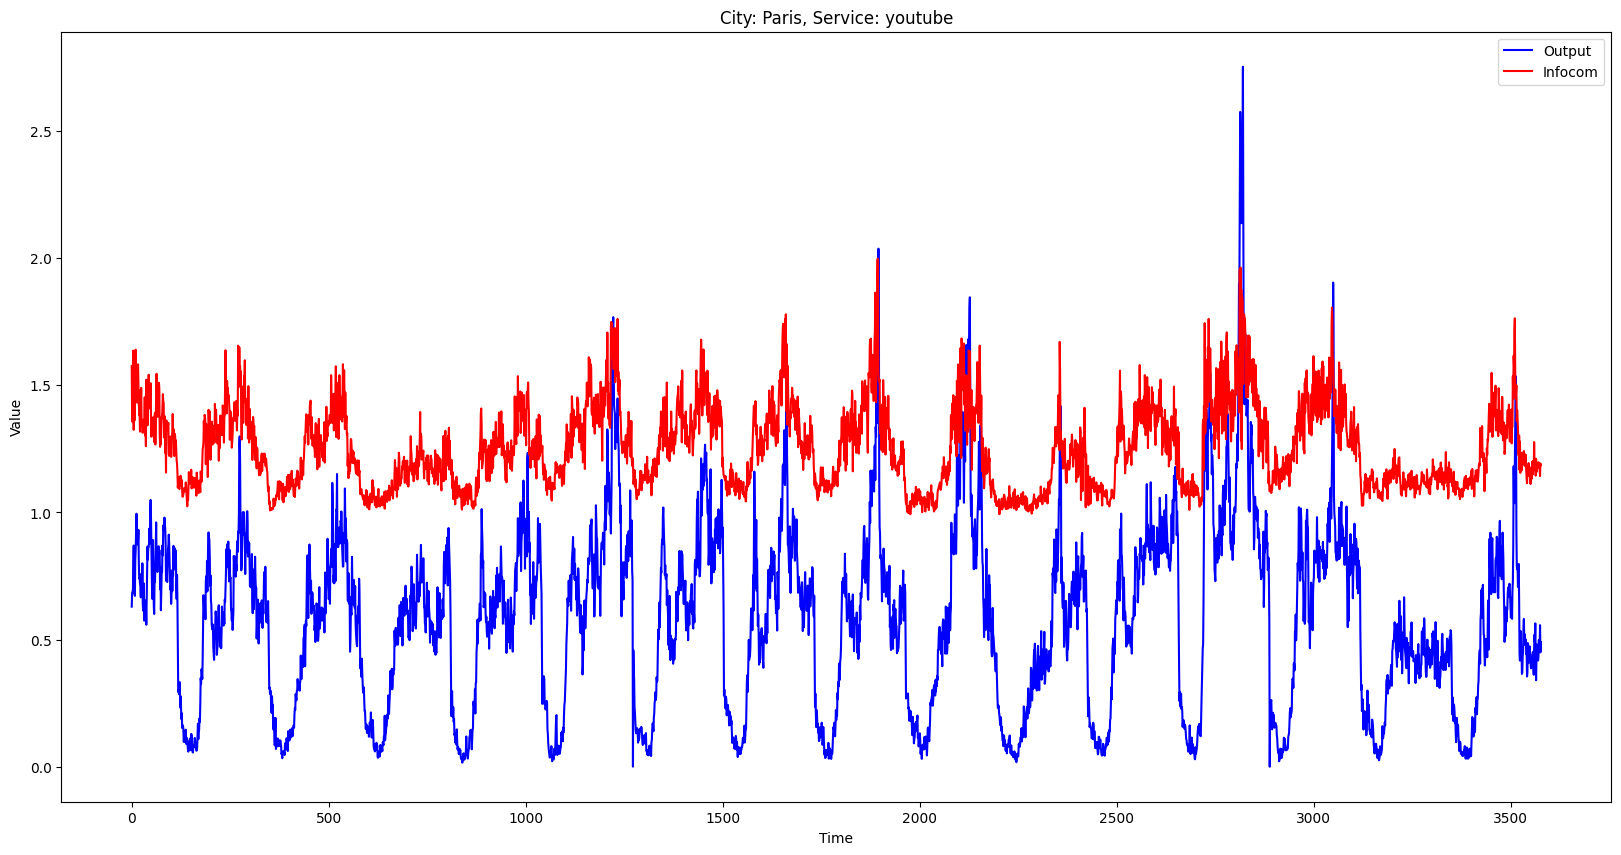

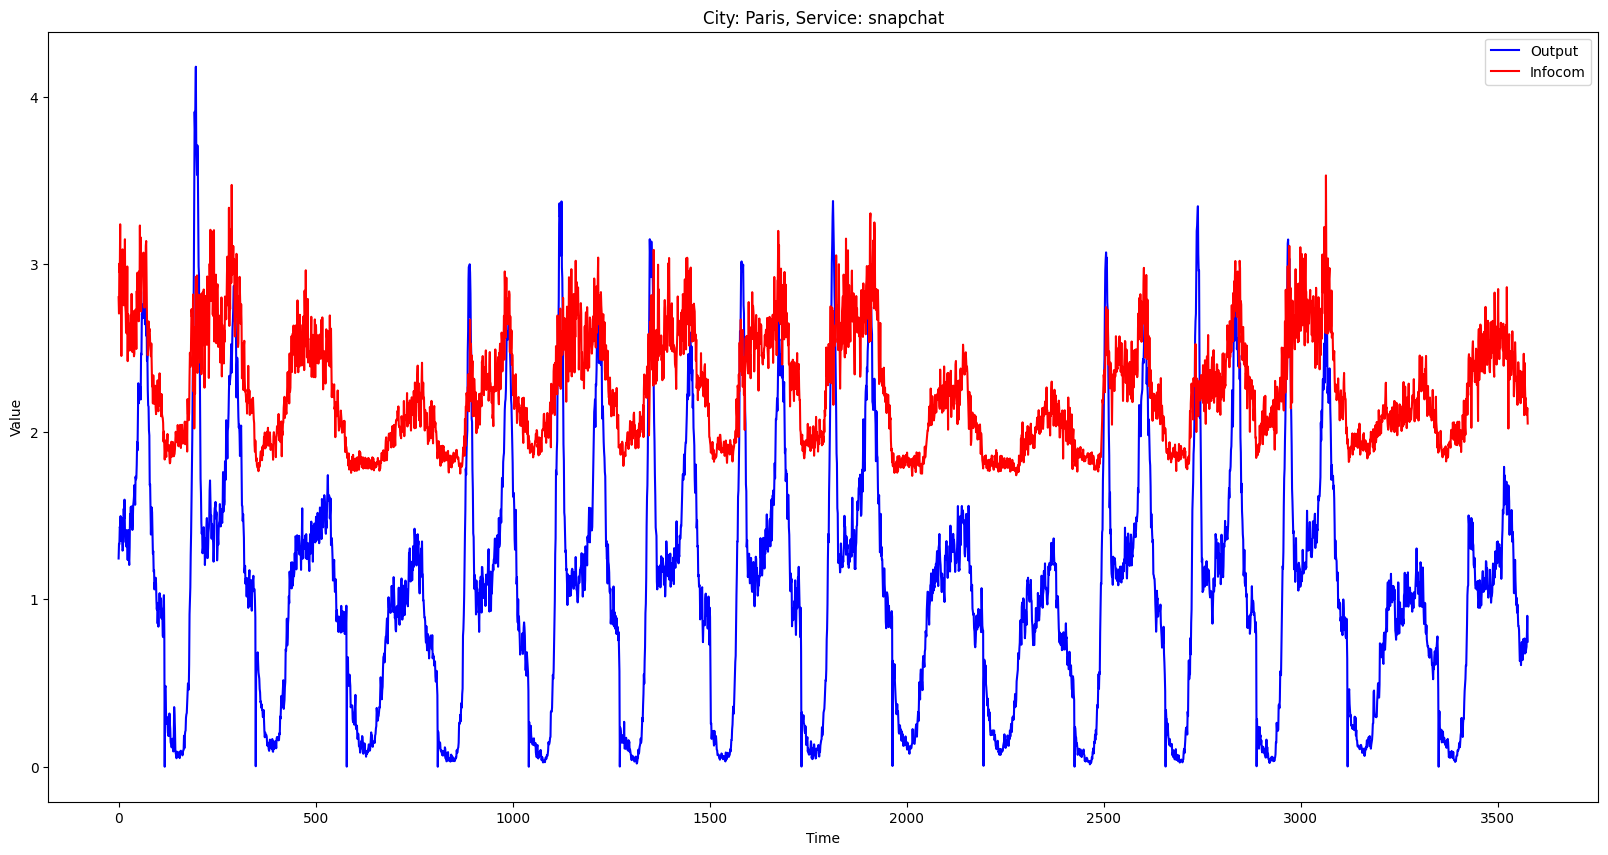

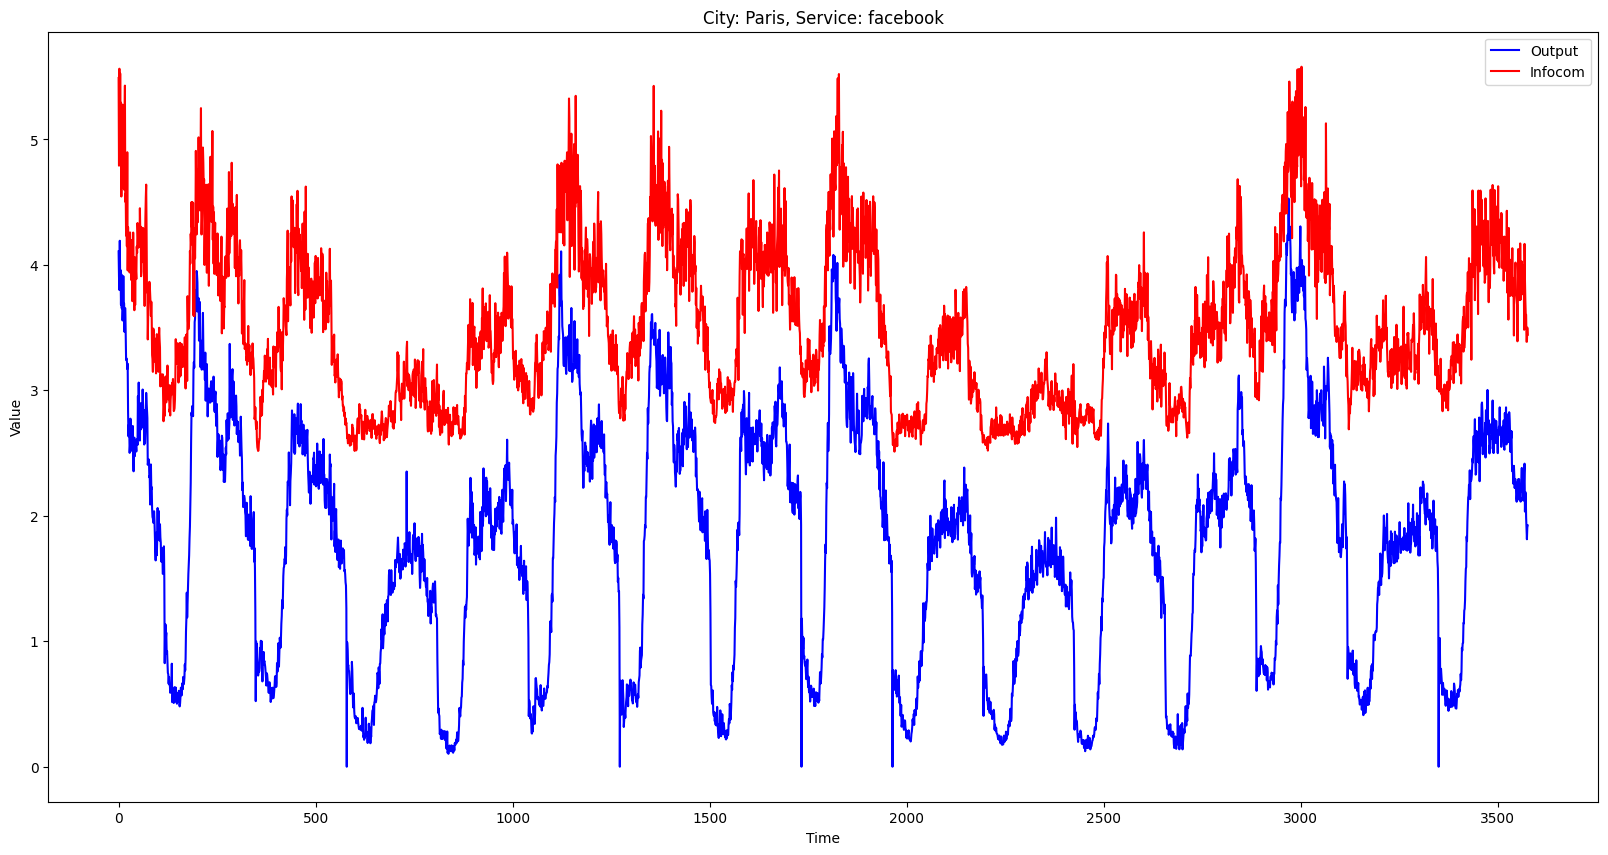

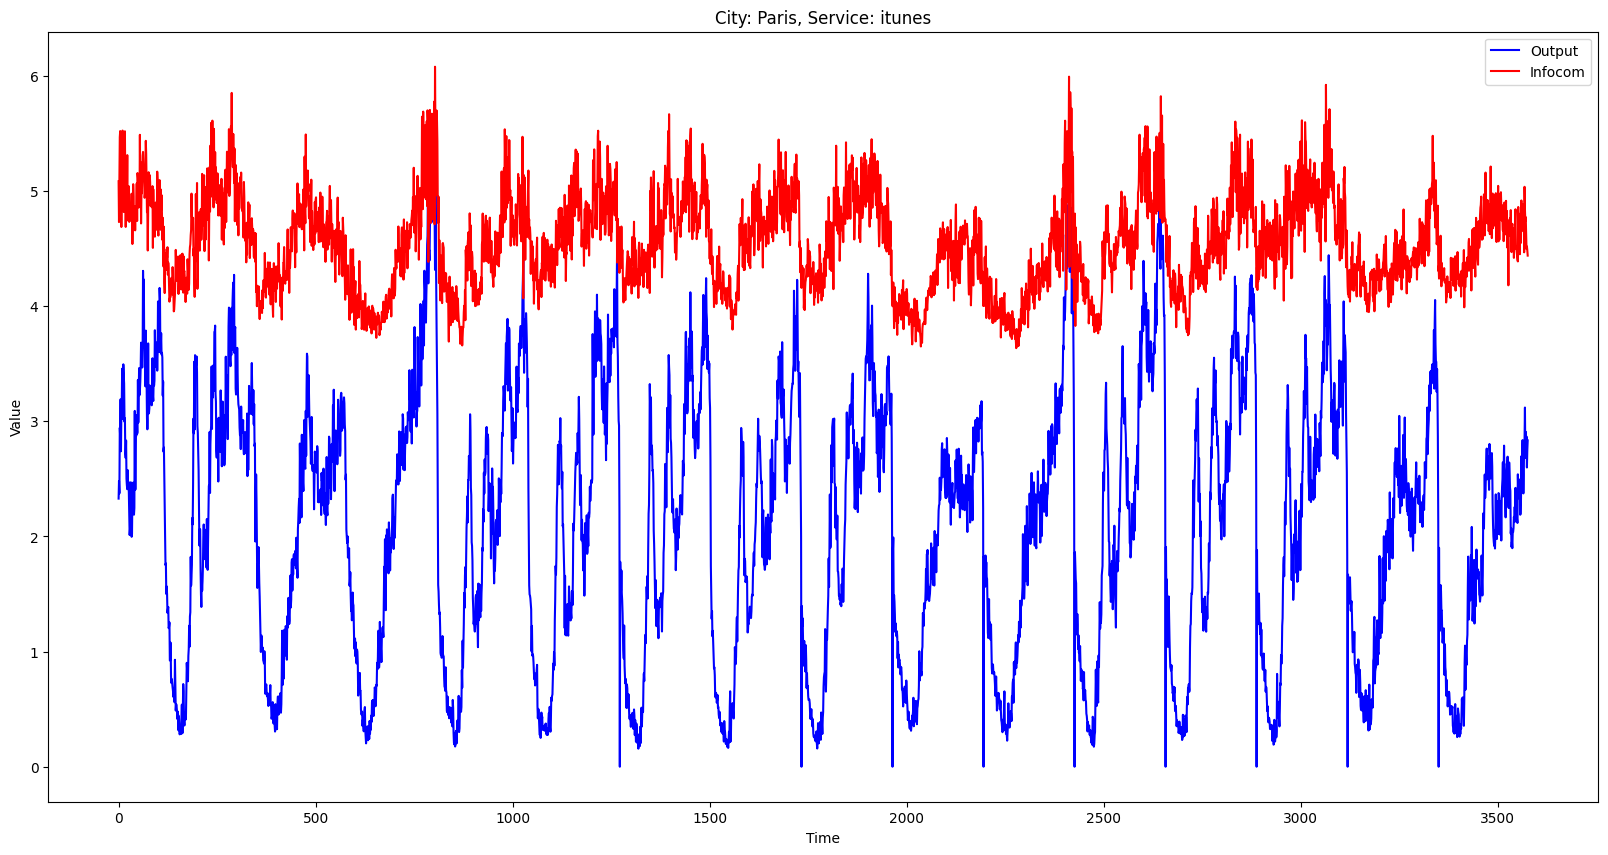

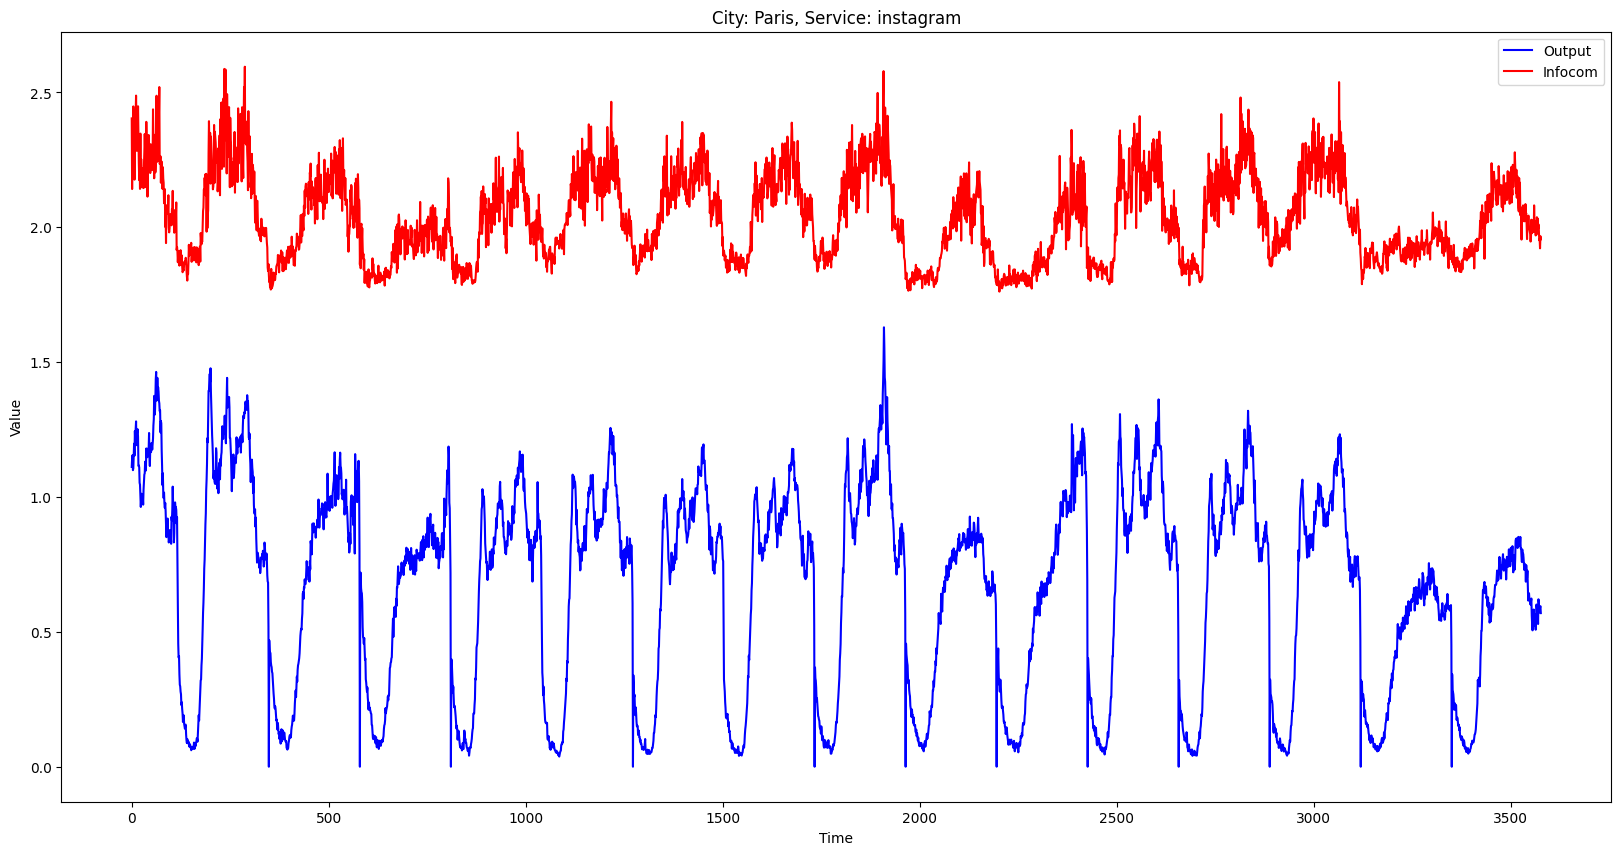

In [17]:
for  i in range(len(services)):
    plt.figure(figsize=(20, 10))
    plt.plot(Output_df_norm[:test_length][:,i], label='Output', color='blue')
    plt.plot(infocom_19_norm[:test_length][:,i], label='Infocom', color='red')
    plt.title(f'City: {city}, Service: {services[i]}')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    
    



In [12]:
cost_df=pd.DataFrame({'total_cost':total_cost_list,'cost_overprovisioning_infocom':cost_overprovisioning_infocom_list,'cost_slas_infocom_19':cost_slas_infocom_19_list,'cost_instantiation_infocom19':cost_instantiation_infocom19_list,'cost_reconfiguration':cost_reconfiguration_list},index=sla_perc_list_index_list)

In [14]:
total_costs = cost_df.total_cost

In [16]:
total_costs.values

array([0.90304008, 1.03258006, 1.28240583, 1.12621791, 1.25608085,
       1.50624967, 3.35799612, 3.49108877, 3.74468809])

In [14]:
cost_df.to_csv(f'FINAL_RESULTS_PARIS/Costs_{city}_delay_{delay}_phi_{phi}_DEEPCOG.csv')

In [13]:
cost_df ### Cost Deepcog

,total_cost,cost_overprovisioning_infocom,cost_slas_infocom_19,cost_instantiation_infocom19,cost_reconfiguration
Paris_phi_0.1_alpha_2_delay_1,0.903040,0.600009,0.031708,0.246526,0.024798
Paris_phi_0.1_alpha_3_delay_1,1.032580,0.730706,0.029565,0.247476,0.024833
Paris_phi_0.1_alpha_5_delay_1,1.282406,0.997454,0.012283,0.247798,0.024872
Paris_phi_0.5_alpha_2_delay_1,1.002230,0.600009,0.031708,0.246526,0.123988
Paris_phi_0.5_alpha_3_delay_1,1.131914,0.730706,0.029565,0.247476,0.124167
Paris_phi_0.5_alpha_5_delay_1,1.381892,0.997454,0.012283,0.247798,0.124358
Paris_phi_1_alpha_2_delay_1,1.126218,0.600009,0.031708,0.246526,0.247975
Paris_phi_1_alpha_3_delay_1,1.256081,0.730706,0.029565,0.247476,0.248334
Paris_phi_1_alpha_5_delay_1,1.506250,0.997454,0.012283,0.247798,0.248715
Paris_phi_10_alpha_2_delay_1,3.357996,0.600009,0.031708,0.246526,2.479754


why many sla, time series aligned?
% SLA
shared capacity well allocated? bad opt? or bad shared cap forecast

SLA viol index, shared total cap check

total, needed, served

block 4




In [ ]:
cost_overprov= (0.6,0.73,0.99)
cost_sla=(0.03,0.02,0.01)
cost_instantiation=(0.246,0.2474,0.24778)
cost_reconf=(0.024798,0.024798,0.024798)

In [18]:
cost_overprovisioning = np.array([0.18780211, 0.19197072, 0.19877882]) # for different alpha

cost_slas = np.array([0.10121839, 0.07697521, 0.08069174]) # for different alpha

cost_instantiation = np.array([0.35578701, 0.37395105, 0.38364393]) # for different alpha and for eta = 2

cost_reconfiguration = np.array([[0.03507828, 0.03685982, 0.03776066],
       						  [0.3507828 , 0.36859822, 0.37760659],
       						  [3.50782801, 3.68598217, 3.7760659 ]])   # row = phis; column = alphas

In [23]:
total_cost_no_inst = cost_overprovisioning + cost_slas + cost_instantiation 

In [26]:
total_cost_no_inst

array([0.64480751, 0.64289698, 0.66311449])

In [28]:
cost_reconfiguration

array([[0.03507828, 0.03685982, 0.03776066],
       [0.3507828 , 0.36859822, 0.37760659],
       [3.50782801, 3.68598217, 3.7760659 ]])

In [24]:
total_cost = cost_overprovisioning + cost_slas + cost_instantiation + cost_reconfiguration

In [25]:
total_cost

array([[0.67988579, 0.6797568 , 0.70087515],
       [0.99559031, 1.0114952 , 1.04072108],
       [4.15263552, 4.32887915, 4.43918039]])